<a href="https://colab.research.google.com/github/Vedanshi18/inventory-demand-forecasting/blob/main/Inventory_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# importing necessary libraries and dataset


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae

import warnings
warnings.filterwarnings('ignore')

# Load and export dataset

In [4]:
# -------------------------------------REMOVE-----------------------------------
df = pd.read_csv("train.csv")
display(df.head())
display(df.tail())

,date,store,item,sales
0,2013-01-01,1,1,13.0
1,2013-01-02,1,1,11.0
2,2013-01-03,1,1,14.0
3,2013-01-04,1,1,13.0
4,2013-01-05,1,1,10.0


,date,store,item,sales
227613,2016-04-04,5,13,64.0
227614,2016-04-05,5,13,68.0
227615,2016-04-06,5,13,65.0
227616,2016-04-07,5,13,78.0
227617,2016-04-08,5,1,NaN


In [ ]:
# -------------------------------------REMOVE-----------------------------------
df.shape

(913000, 4)

In [ ]:
# -------------------------------------REMOVE-----------------------------------
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
# -------------------------------------REMOVE-----------------------------------
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


# Feature Engineering

In [5]:
parts = df["date"].str.split("-", n =3, expand = True)
df["year"] = parts[0].astype('int')
df["month"] = parts[1].astype('int')
df["day"] = parts[2].astype('int')
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13.0,2013,1,1
1,2013-01-02,1,1,11.0,2013,1,2
2,2013-01-03,1,1,14.0,2013,1,3
3,2013-01-04,1,1,13.0,2013,1,4
4,2013-01-05,1,1,10.0,2013,1,5


checking the effect of day on requirements to fulfill the demands

checking weekend/ weekday :

In [6]:
from datetime import datetime

def weekend_or_weekday(year, month, day):
  d = datetime(year, month, day)
  # 1 == weekend & 0 == weekday
  #d.weekday is a built-in method of datetime object
  return 1 if d.weekday() > 4 else 0


#df.apply() --> iterates through each row of the DataFrame and applies the weekend_or_weekday function to the relevant columns of that row,
#               returning a new DataFrame which is then assigned to the 'weekend' column.
# axis 1 = row-wise, axis 0 = column-wise
df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis =1)

df.head()

,date,store,item,sales,year,month,day,weekend
0,2013-01-01,1,1,13.0,2013,1,1,0
1,2013-01-02,1,1,11.0,2013,1,2,0
2,2013-01-03,1,1,14.0,2013,1,3,0
3,2013-01-04,1,1,13.0,2013,1,4,0
4,2013-01-05,1,1,10.0,2013,1,5,1


checking for holiday

In [7]:
from datetime import date
import holidays

india_holidays = holidays.country_holidays('IN')
# 1 == holiday in india, 0 == not holiday
df['holidays'] = df['date'].apply(lambda x: 1 if india_holidays.get(x) else 0)

display(df.head())

# Display the row for August 15, 2013 to check the holiday flag
display(df[df['date'] == '2013-08-15'])

,date,store,item,sales,year,month,day,weekend,holidays
0,2013-01-01,1,1,13.0,2013,1,1,0,0
1,2013-01-02,1,1,11.0,2013,1,2,0,0
2,2013-01-03,1,1,14.0,2013,1,3,0,0
3,2013-01-04,1,1,13.0,2013,1,4,0,0
4,2013-01-05,1,1,10.0,2013,1,5,1,0


,date,store,item,sales,year,month,day,weekend,holidays
226,2013-08-15,1,1,22.0,2013,8,15,0,1
2052,2013-08-15,2,1,26.0,2013,8,15,0,1
3878,2013-08-15,3,1,23.0,2013,8,15,0,1
5704,2013-08-15,4,1,12.0,2013,8,15,0,1
7530,2013-08-15,5,1,21.0,2013,8,15,0,1
...,...,...,...,...,...,...,...,...,...
219346,2013-08-15,1,13,76.0,2013,8,15,0,1
221172,2013-08-15,2,13,110.0,2013,8,15,0,1
222998,2013-08-15,3,13,98.0,2013,8,15,0,1
224824,2013-08-15,4,13,78.0,2013,8,15,0,1


generally used in machine learning tasks, especially when dealing with time-series data or any feature that is inherently cyclical. Common applications include:

**Time Series Forecasting**: Predicting sales, weather, energy consumption, etc., where daily, weekly, monthly, or yearly patterns are crucial. <br>
**Demand Prediction**: As in your current dataset, predicting sales often has strong monthly or seasonal components. <br>
**Recommendation Systems**: Understanding seasonal preferences for products. <br>
**Any model that struggles with ordinal cyclical data**: Linear models (like Linear Regression, Ridge, Lasso) and tree-based models (like Random Forest, XGBoost) can benefit significantly. For example, a linear model would see month 12 as numerically very far from month 1, potentially missing the actual closeness in time. These sine/cosine features solve that problem.

This code is performing feature engineering on the 'month' column to handle its cyclical nature. Months are cyclical (January follows December), so a simple numerical representation might not capture this relationship well. Transforming them using sine and cosine functions allows machine learning models to understand this cyclical pattern.

 For example, month 1 (January) would be mapped to an angle, and month 12 (December) would be mapped to an angle close to month 1, capturing the cyclical relationship.

In [9]:
#
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))
df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2
0,2013-01-01,1,1,13.0,2013,1,1,0,0,0.5,0.866025
1,2013-01-02,1,1,11.0,2013,1,2,0,0,0.5,0.866025
2,2013-01-03,1,1,14.0,2013,1,3,0,0,0.5,0.866025
3,2013-01-04,1,1,13.0,2013,1,4,0,0,0.5,0.866025
4,2013-01-05,1,1,10.0,2013,1,5,1,0,0.5,0.866025


indicating which day of the week it is

In [10]:
def which_day(year, month, day):
  return datetime(year, month, day).weekday()

df['weekday'] = df.apply(lambda x: which_day(x['year'], x['month'], x['day']), axis =1)

df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,2013-01-01,1,1,13.0,2013,1,1,0,0,0.5,0.866025,1
1,2013-01-02,1,1,11.0,2013,1,2,0,0,0.5,0.866025,2
2,2013-01-03,1,1,14.0,2013,1,3,0,0,0.5,0.866025,3
3,2013-01-04,1,1,13.0,2013,1,4,0,0,0.5,0.866025,4
4,2013-01-05,1,1,10.0,2013,1,5,1,0,0.5,0.866025,5


removing columns that are not useful

In [11]:
df.drop('date', axis=1, inplace=True)

df.head()

,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,1,1,13.0,2013,1,1,0,0,0.5,0.866025,1
1,1,1,11.0,2013,1,2,0,0,0.5,0.866025,2
2,1,1,14.0,2013,1,3,0,0,0.5,0.866025,3
3,1,1,13.0,2013,1,4,0,0,0.5,0.866025,4
4,1,1,10.0,2013,1,5,1,0,0.5,0.866025,5


#Exploratory data analysis

Used to discover trends, and patterns or to check assumptions with the help of statistical summaries and graphical representations

In [ ]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

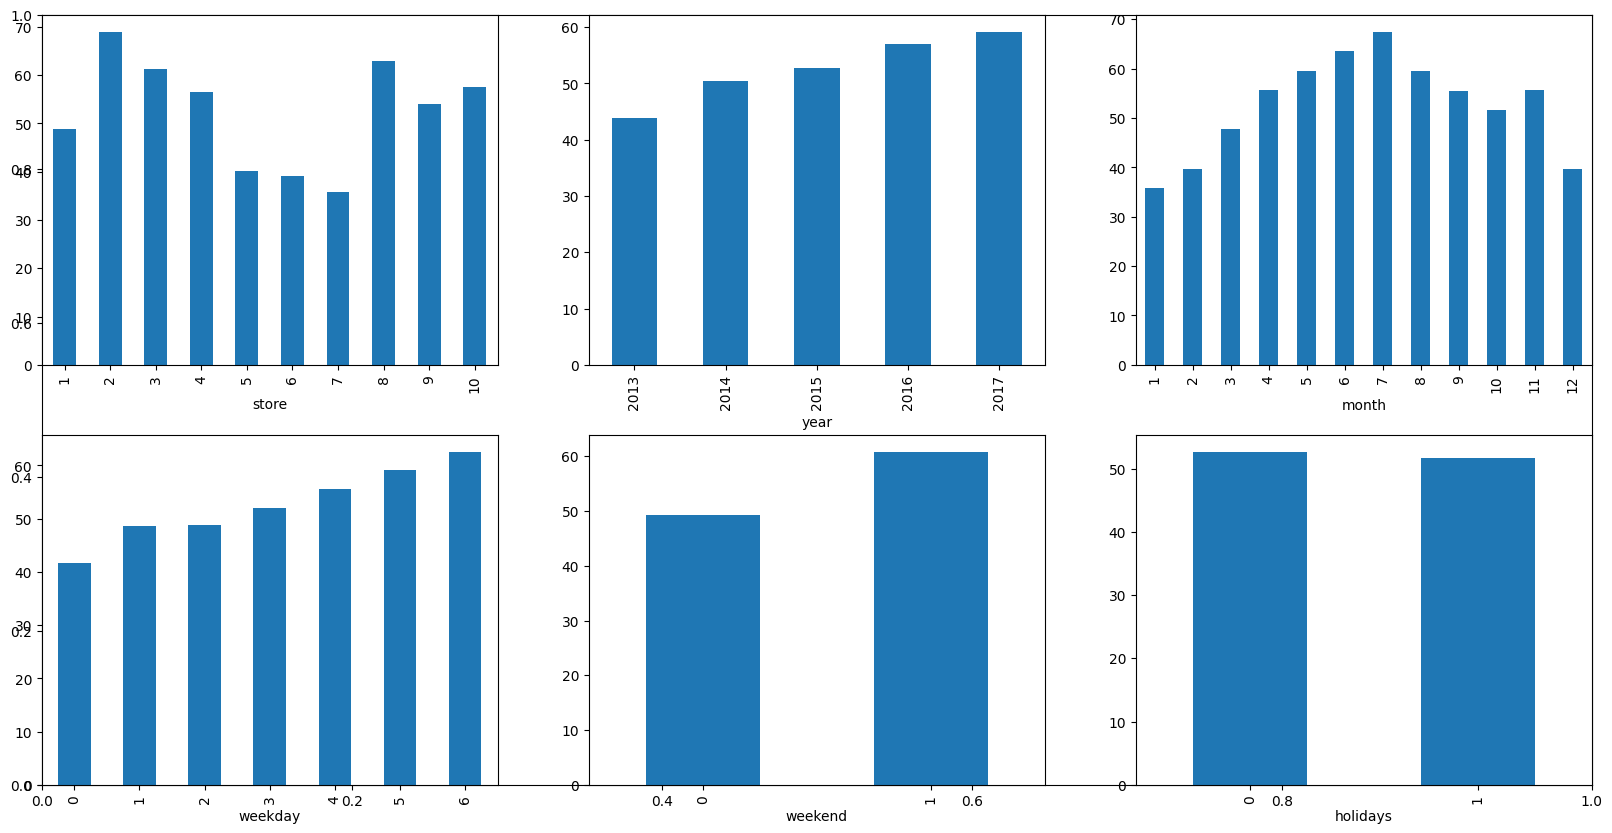

In [12]:
# groups the data by current column and calculate the mean sales of each group and plot a bar chart to show the averages for each category of features.

df['weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

plt.subplots(figsize = (20,10))
for i, col in enumerate(features):
  plt.subplot(2, 3, i+1)
  df.groupby(col).mean()['sales'].plot.bar()
plt.show()

checking variation of stock as the month closes to the end using line plot

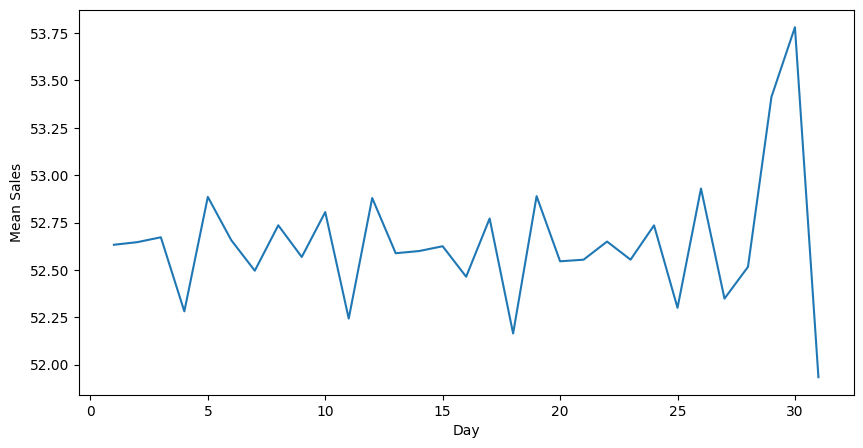

In [15]:
plt.figure(figsize=(10,5))
df.groupby('day').mean()['sales'].plot()
plt.xlabel("Day")
plt.ylabel("Mean Sales")
plt.show()

Plotting simple moving average will help smooth out short-term fluctuations and highlight longer-term trends or cycles in the data 😵‍💫

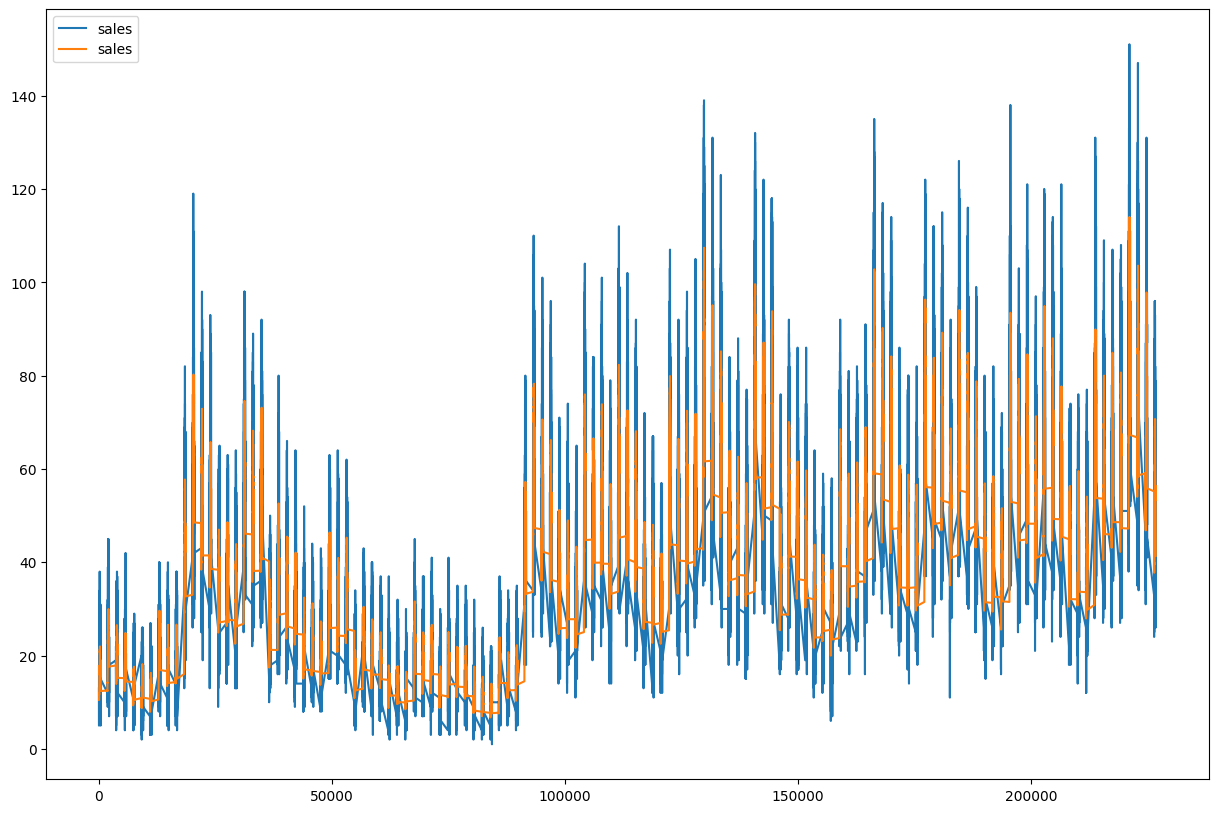

In [16]:
plt.figure(figsize = (15, 10))

# calculating simple moving average for a window period of 30 days
window_size = 30
data = df[df['year'] == 2013]
windows = data['sales'].rolling(window_size)
sma = windows.mean()
sma = sma[window_size -1:]

data['sales'].plot()
sma.plot()
plt.legend()
plt.show()

Checking distribution of the data and check whether there are some outliers in this column or not, using distplot and boxplot.

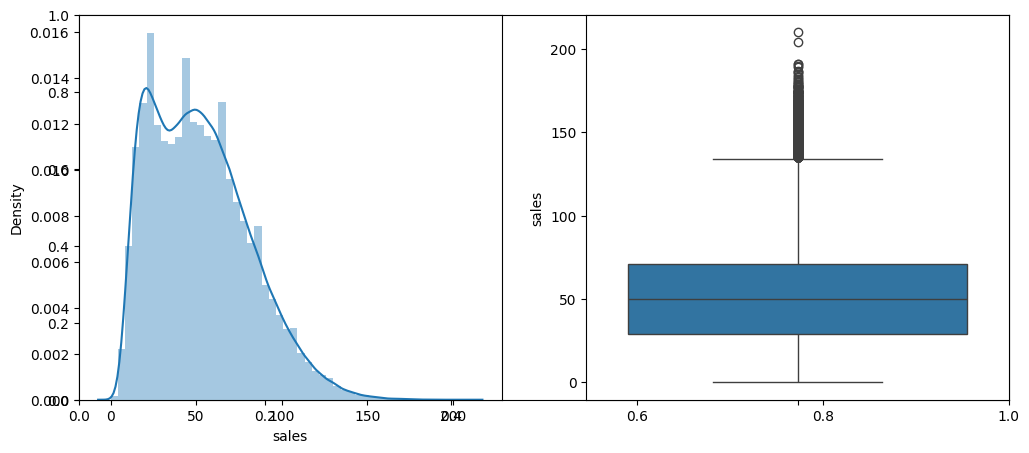

In [18]:
plt.subplots(figsize=(12,5))
plt.subplot(1, 2, 1)
sb.distplot(df['sales'])

plt.subplot(1, 2, 2)
sb.boxplot(df['sales'])
plt.show()

From above graph, we can observe that the distribution is right skewed and the dataset contains outliers.

checking the correlation between the features of the data and added a filter to identify only the highly correlated features.

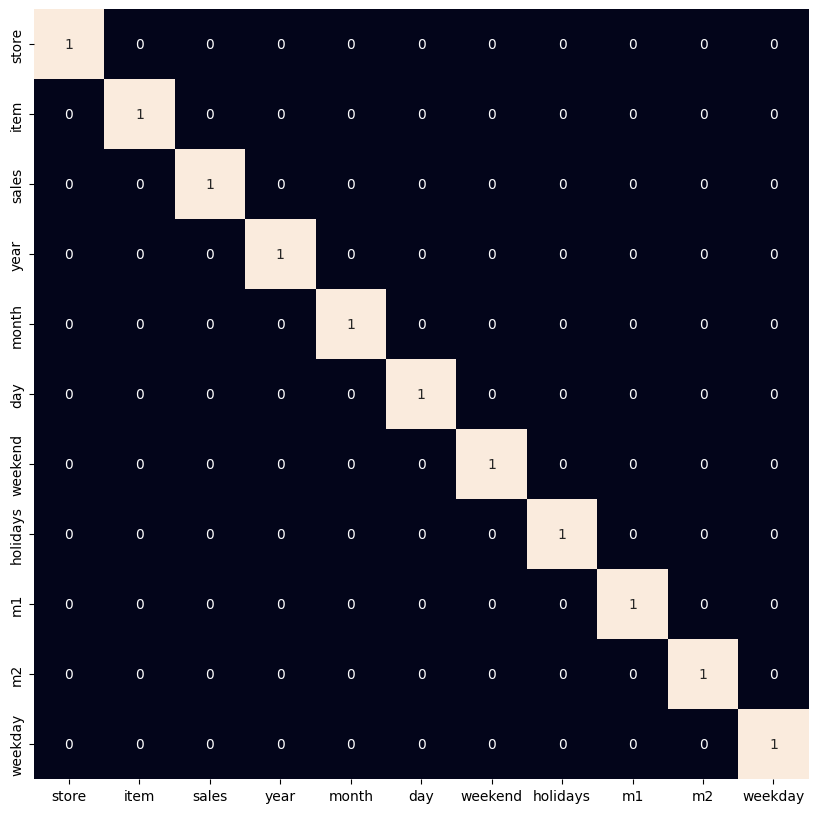

In [20]:
plt.figure(figsize=(10,10))
sb.heatmap(df.corr() > 0.8, annot = True, cbar = False)
plt.show()

removing the outliers which are present in the data.

In [21]:
df = df[df['sales'] < 140]

#Model Training

 separate the features and target variables and split them into training and the testing data by using which we will select the model which is performing best on the validation data.

In [25]:
features = df.drop(['sales', 'year'], axis=1)
target = df['sales'].values

X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size = 0.05, random_state =22)

X_train.shape, X_val.shape

((215270, 9), (11330, 9))

Normalizing the data before feeding it into machine learning models helps us to achieve stable and fast training.

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

train machine learning models and select the best out of them using the validation dataset.

For this implementation, we have used Linear Regression, XGBoost, Lasso Regression and Ridge Regression.

In [28]:
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()]

for i in range (4):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')

  train_preds = models[i].predict(X_train)
  print('Training Error : ',mae(Y_train, train_preds))

  val_preds = models[i].predict(X_val)
  print('Validation Error : ', mae(Y_val, val_preds))
  print()

LinearRegression() : 
Training Error :  16.764110068156107
Validation Error :  16.6801001504304

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  6.482528564258465
Validation Error :  6.594056158621334

Lasso() : 
Training Error :  16.875706363877644
Validation Error :  16.79809

After training and evaluating the models, we observe that XGBoost performs the best with the lowest validation error. This demonstrates the power of ensemble methods in capturing complex patterns in sales data.